<h1 style="text-align:center; border:2.5px solid rgb(72, 208, 242)">  The Z-Distribution </h1>


<b> Kyla Faith A. Pedrajas </b>
<br> Computer Engineer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#Load Dataset
df = pd.read_csv(r"dataset\transformer-voltage.csv",
                 index_col='Sample',
                 delimiter=",")
df



,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [4]:
#Summary of Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [5]:
#SUmmary of Statistics
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [7]:
#Z-Critical for Two-Tailed Test
alpha = 0.01
Z_critical = stats.norm.ppf(1 - alpha/2)
Z_critical

np.float64(2.5758293035489004)

In [9]:
#COnfidence Interval
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)

print(f"Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

Confidence Interval: [118.50, 122.08]


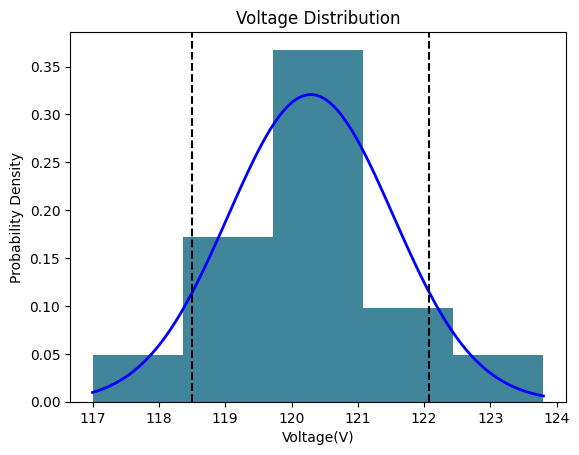

In [12]:
#Voltage Distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

#x-axis
x_min = df['Voltage'].min() 
x_max = df['Voltage'].max()

#Normal DIstribution Plot
x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)
plt.plot(x, p, 
         linewidth = 2,
         color='blue')

#Histogram
plt.hist(df['Voltage'], 
         bins=5, 
         density=True, 
         alpha=0.8, 
         color='#126782')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage(V)')

#Confidence Interval
plt.axvline(x=ci_lower,
            color = 'black',
            linestyle = '--')
plt.axvline(x=ci_upper,
            color = 'black',
            linestyle = '--')
plt.show()